In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Bond Data
bond = pd.read_csv("US037833DB33=TX Overview.csv")

# Load SOFR Data
sofr = pd.read_excel("SOFR.xlsx", sheet_name="Daily")

# Display first few rows
display(bond)
display(sofr)

,Date,Price,Open,High,Low,Change %
0,03/31/2026,98.53,98.52,98.53,98.53,0.01%
1,03/30/2026,98.52,98.52,98.52,98.52,0.34%
2,03/28/2026,98.19,98.35,98.19,98.19,0.00%
3,03/27/2026,98.19,98.35,98.19,98.19,-0.16%
4,03/26/2026,98.35,98.35,98.35,98.35,0.04%
...,...,...,...,...,...,...
412,05/03/2023,97.06,97.06,97.06,97.06,1.15%
413,04/21/2023,95.96,95.96,95.96,95.96,-0.29%
414,04/20/2023,96.24,96.24,96.24,96.24,-0.27%
415,04/17/2023,96.50,96.50,96.50,96.50,0.09%


,observation_date,SOFR
0,2023-04-03,4.84
1,2023-04-04,4.83
2,2023-04-05,4.81
3,2023-04-06,4.81
4,2023-04-07,NaN
...,...,...
777,2026-03-25,3.64
778,2026-03-26,3.65
779,2026-03-27,3.63
780,2026-03-30,3.63


In [19]:
# Standardize column names
bond.columns = bond.columns.str.strip()

# Standardize date separators
bond["Date"] = bond["Date"].astype(str).str.replace("-", "/", regex=False)

# Convert to datetime
bond["Date"] = pd.to_datetime(bond["Date"], format="%m/%d/%Y")

# Convert Price to numeric
bond["Price"] = (
    bond["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Keep only required columns
bond = bond[["Date", "Price"]]

# Sort chronologically
bond = bond.sort_values("Date").reset_index(drop=True)

bond

,Date,Price
0,2023-04-05,96.41
1,2023-04-17,96.50
2,2023-04-20,96.24
3,2023-04-21,95.96
4,2023-05-03,97.06
...,...,...
412,2026-03-26,98.35
413,2026-03-27,98.19
414,2026-03-28,98.19
415,2026-03-30,98.52


In [20]:
# Rename column
sofr = sofr.rename(columns={"observation_date": "Date"})

# Convert Date to datetime
sofr["Date"] = pd.to_datetime(sofr["Date"])

# Convert SOFR from % to decimal
sofr["SOFR"] = sofr["SOFR"] / 100

# Sort chronologically
sofr = sofr.sort_values("Date").reset_index(drop=True)

sofr.head()

,Date,SOFR
0,2023-04-03,0.0484
1,2023-04-04,0.0483
2,2023-04-05,0.0481
3,2023-04-06,0.0481
4,2023-04-07,NaN


In [21]:
# Create a business-day calendar spanning the bond data
calendar = pd.DataFrame({
    "Date": pd.date_range(
        start=bond["Date"].min(),
        end=bond["Date"].max(),
        freq="B"
    )
})

# Merge bond prices
df = calendar.merge(bond, on="Date", how="left")

# Forward-fill missing bond prices
df["Price"] = df["Price"].ffill()

# Merge SOFR
df = df.merge(sofr, on="Date", how="left")

# Forward-fill SOFR for holidays/weekends
df["SOFR"] = df["SOFR"].ffill()

# Check the final dataset
print(df.shape)
df.head(10)

(780, 3)


,Date,Price,SOFR
0,2023-04-05,96.41,0.0481
1,2023-04-06,96.41,0.0481
2,2023-04-07,96.41,0.0481
3,2023-04-10,96.41,0.0481
4,2023-04-11,96.41,0.0480
5,2023-04-12,96.41,0.0480
6,2023-04-13,96.41,0.0480
7,2023-04-14,96.41,0.0480
8,2023-04-17,96.50,0.0480
9,2023-04-18,96.50,0.0480


In [22]:
# ==========================
# Bond Characteristics
# ==========================

FACE_VALUE = 1000                  # Face value per bond ($)
COUPON_RATE = 0.029                # 2.90% annual coupon
COUPON_FREQUENCY = 2               # Semi-annual coupons

# ==========================
# Position Details
# ==========================

POSITION_FACE = 10_000_000         # $10 million face value position

# Number of bonds held
NUM_BONDS = POSITION_FACE / FACE_VALUE

# ==========================
# Repo Assumptions
# ==========================

HAIRCUT = 0.15                   # 15%
REPO_SPREAD = 0.0030               # SOFR + 30 bps

# Initial Market Value
INITIAL_PRICE = df["Price"].iloc[0]

INITIAL_MARKET_VALUE = NUM_BONDS * (INITIAL_PRICE / 100) * FACE_VALUE

# Initial Repo Loan
INITIAL_REPO_LOAN = INITIAL_MARKET_VALUE * (1 - HAIRCUT)

# Initial Equity
INITIAL_EQUITY = INITIAL_MARKET_VALUE - INITIAL_REPO_LOAN

print(f"Initial Market Value : ${INITIAL_MARKET_VALUE:,.2f}")
print(f"Initial Repo Loan    : ${INITIAL_REPO_LOAN:,.2f}")
print(f"Initial Equity       : ${INITIAL_EQUITY:,.2f}")

Initial Market Value : $9,641,000.00
Initial Repo Loan    : $8,194,850.00
Initial Equity       : $1,446,150.00


In [23]:
# ==========================
# Repo Financing Calculations
# ==========================

# Market Value of Bond Position
df["Market_Value"] = NUM_BONDS * (df["Price"] / 100) * FACE_VALUE

# Repo Loan (constant)
df["Repo_Loan"] = INITIAL_REPO_LOAN

# Repo Rate
df["Repo_Rate"] = df["SOFR"] + REPO_SPREAD

# Daily Financing Cost
df["Daily_Financing_Cost"] = (
    df["Repo_Loan"] * df["Repo_Rate"] / 365
)

# Cumulative Financing Cost
df["Cumulative_Financing_Cost"] = df["Daily_Financing_Cost"].cumsum()

# Equity
df["Equity"] = df["Market_Value"] - df["Repo_Loan"]

# Loan-to-Value
df["LTV"] = df["Repo_Loan"] / df["Market_Value"]

In [24]:
# ==========================
# Performance Metrics
# ==========================

# Unrealized Profit / Loss
df["Unrealized_PnL"] = df["Market_Value"] - INITIAL_MARKET_VALUE

# Equity after financing cost
df["Adjusted_Equity"] = df["Equity"] - df["Cumulative_Financing_Cost"]

# Net Profit after financing cost
df["Net_PnL"] = df["Unrealized_PnL"] - df["Cumulative_Financing_Cost"]

# Return on Equity
df["ROE"] = df["Net_PnL"] / INITIAL_EQUITY

# Display
# Display a cleaner view
display(
    df.head(10).style.format({
        "Price": "{:.2f}",
        "SOFR": "{:.2%}",
        "Market_Value": "${:,.2f}",
        "Repo_Loan": "${:,.2f}",
        "Repo_Rate": "{:.2%}",
        "Daily_Financing_Cost": "${:,.2f}",
        "Cumulative_Financing_Cost": "${:,.2f}",
        "Equity": "${:,.2f}",
        "LTV": "{:.2%}",
        "Daily_MTM": "${:,.2f}",
        "Cumulative_MTM": "${:,.2f}",
        "Net_Equity": "${:,.2f}",
        "ROE": "{:.2%}"
    })
)

,Date,Price,SOFR,Market_Value,Repo_Loan,Repo_Rate,Daily_Financing_Cost,Cumulative_Financing_Cost,Equity,LTV,Unrealized_PnL,Adjusted_Equity,Net_PnL,ROE
0,2023-04-05 00:00:00,96.41,4.81%,"$9,641,000.00","$8,194,850.00",5.11%,"$1,147.28","$1,147.28","$1,446,150.00",85.00%,0.000000,1445002.721000,-1147.279000,-0.08%
1,2023-04-06 00:00:00,96.41,4.81%,"$9,641,000.00","$8,194,850.00",5.11%,"$1,147.28","$2,294.56","$1,446,150.00",85.00%,0.000000,1443855.442000,-2294.558000,-0.16%
2,2023-04-07 00:00:00,96.41,4.81%,"$9,641,000.00","$8,194,850.00",5.11%,"$1,147.28","$3,441.84","$1,446,150.00",85.00%,0.000000,1442708.163000,-3441.837000,-0.24%
3,2023-04-10 00:00:00,96.41,4.81%,"$9,641,000.00","$8,194,850.00",5.11%,"$1,147.28","$4,589.12","$1,446,150.00",85.00%,0.000000,1441560.884000,-4589.116000,-0.32%
4,2023-04-11 00:00:00,96.41,4.80%,"$9,641,000.00","$8,194,850.00",5.10%,"$1,145.03","$5,734.15","$1,446,150.00",85.00%,0.000000,1440415.850164,-5734.149836,-0.40%
5,2023-04-12 00:00:00,96.41,4.80%,"$9,641,000.00","$8,194,850.00",5.10%,"$1,145.03","$6,879.18","$1,446,150.00",85.00%,0.000000,1439270.816329,-6879.183671,-0.48%
6,2023-04-13 00:00:00,96.41,4.80%,"$9,641,000.00","$8,194,850.00",5.10%,"$1,145.03","$8,024.22","$1,446,150.00",85.00%,0.000000,1438125.782493,-8024.217507,-0.55%
7,2023-04-14 00:00:00,96.41,4.80%,"$9,641,000.00","$8,194,850.00",5.10%,"$1,145.03","$9,169.25","$1,446,150.00",85.00%,0.000000,1436980.748658,-9169.251342,-0.63%
8,2023-04-17 00:00:00,96.50,4.80%,"$9,650,000.00","$8,194,850.00",5.10%,"$1,145.03","$10,314.29","$1,455,150.00",84.92%,9000.000000,1444835.714822,-1314.285178,-0.09%
9,2023-04-18 00:00:00,96.50,4.80%,"$9,650,000.00","$8,194,850.00",5.10%,"$1,145.03","$11,459.32","$1,455,150.00",84.92%,9000.000000,1443690.680986,-2459.319014,-0.17%


In [25]:
# ==========================
# Margin Call Monitoring
# ==========================

# Margin call threshold (maximum acceptable LTV)
MARGIN_CALL_LTV = 0.90

# Additional collateral required to restore LTV to the threshold
df["Margin_Call_Amount"] = np.where(
    df["LTV"] > MARGIN_CALL_LTV,
    df["Repo_Loan"] - (MARGIN_CALL_LTV * df["Market_Value"]),
    0
)

# Flag days on which a margin call occurs
df["Margin_Call"] = np.where(
    df["Margin_Call_Amount"] > 0,
    "Yes",
    "No"
)

# Summary statistics
print(f"Total Margin Calls : {(df['Margin_Call'] == 'Yes').sum()}")
print(f"Maximum Margin Call: ${df['Margin_Call_Amount'].max():,.2f}")

# Display only days with margin calls
display(
    df.loc[df["Margin_Call"] == "Yes",
           ["Date", "Price", "Market_Value", "Repo_Loan",
            "LTV", "Margin_Call_Amount"]]
    .style.format({
        "Price": "{:.2f}",
        "Market_Value": "${:,.2f}",
        "Repo_Loan": "${:,.2f}",
        "LTV": "{:.2%}",
        "Margin_Call_Amount": "${:,.2f}"
    })
)

Total Margin Calls : 0
Maximum Margin Call: $0.00


,Date,Price,Market_Value,Repo_Loan,LTV,Margin_Call_Amount


In [26]:
# ==========================
# Coupon Cash Flow Engine
# ==========================

# Coupon payment dates (Semi-Annual: March 12 & September 12)
coupon_dates = pd.to_datetime([
    "2023-09-12",
    "2024-03-12",
    "2024-09-12",
    "2025-03-12",
    "2025-09-12",
    "2026-03-12"
])

# Coupon received per payment
COUPON_PAYMENT = POSITION_FACE * (COUPON_RATE / COUPON_FREQUENCY)

# Coupon received on payment dates
df["Coupon_Income"] = np.where(
    df["Date"].isin(coupon_dates),
    COUPON_PAYMENT,
    0.0
)

# Running coupon income
df["Cumulative_Coupon_Income"] = df["Coupon_Income"].cumsum()

# Updated Net P&L
df["Net_PnL"] = (
    df["Unrealized_PnL"]
    + df["Cumulative_Coupon_Income"]
    - df["Cumulative_Financing_Cost"]
)

# Updated ROE
df["ROE"] = df["Net_PnL"] / INITIAL_EQUITY

# View coupon payment dates
display(
    df[df["Coupon_Income"] > 0][
        ["Date", "Coupon_Income", "Cumulative_Coupon_Income"]
    ].style.format({
        "Coupon_Income": "${:,.2f}",
        "Cumulative_Coupon_Income": "${:,.2f}"
    })
)

,Date,Coupon_Income,Cumulative_Coupon_Income
114,2023-09-12 00:00:00,"$145,000.00","$145,000.00"
244,2024-03-12 00:00:00,"$145,000.00","$290,000.00"
376,2024-09-12 00:00:00,"$145,000.00","$435,000.00"
505,2025-03-12 00:00:00,"$145,000.00","$580,000.00"
637,2025-09-12 00:00:00,"$145,000.00","$725,000.00"
766,2026-03-12 00:00:00,"$145,000.00","$870,000.00"


In [27]:
# ==========================
# Portfolio Performance Summary
# ==========================

summary = pd.DataFrame({
    "Metric": [
        "Initial Market Value",
        "Final Market Value",
        "Total Unrealized P&L",
        "Total Coupon Income",
        "Total Financing Cost",
        "Net P&L",
        "Final Equity",
        "Final LTV",
        "Final ROE"
    ],
    "Value": [
        INITIAL_MARKET_VALUE,
        df["Market_Value"].iloc[-1],
        df["Unrealized_PnL"].iloc[-1],
        df["Cumulative_Coupon_Income"].iloc[-1],
        df["Cumulative_Financing_Cost"].iloc[-1],
        df["Net_PnL"].iloc[-1],
        df["Equity"].iloc[-1],
        df["LTV"].iloc[-1],
        df["ROE"].iloc[-1]
    ]
})

display(
    summary.style.format({
        "Value": lambda x: (
            f"{x:.2%}" if abs(x) < 1
            else f"${x:,.2f}"
        )
    })
)

,Metric,Value
0,Initial Market Value,"$9,641,000.00"
1,Final Market Value,"$9,853,000.00"
2,Total Unrealized P&L,"$212,000.00"
3,Total Coupon Income,"$870,000.00"
4,Total Financing Cost,"$880,769.01"
5,Net P&L,"$201,230.99"
6,Final Equity,"$1,658,150.00"
7,Final LTV,83.17%
8,Final ROE,13.91%


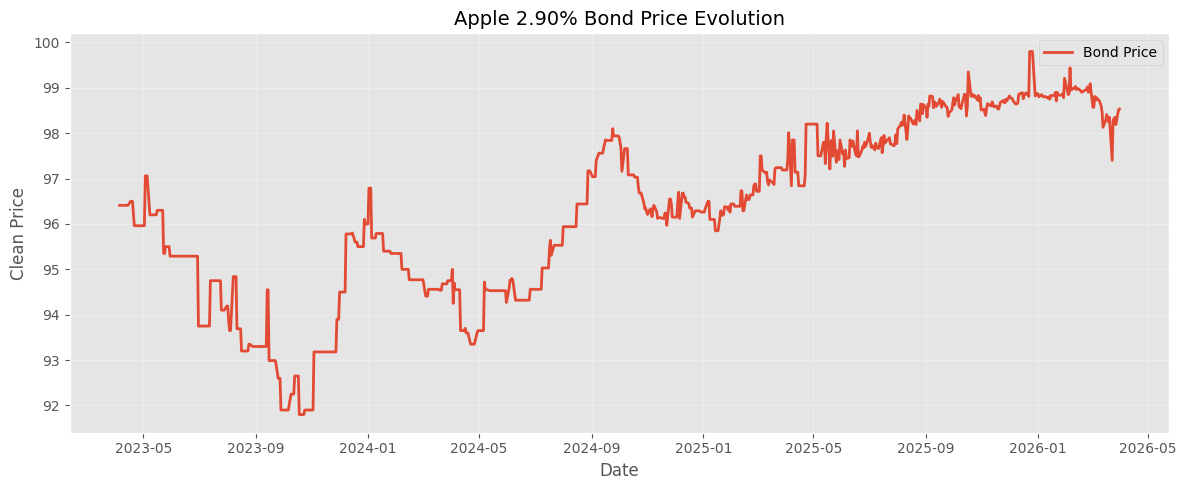

In [28]:
# ==========================
# Bond Price Evolution
# ==========================

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Price"],
    linewidth=2,
    label="Bond Price"
)

plt.title("Apple 2.90% Bond Price Evolution", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Clean Price")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

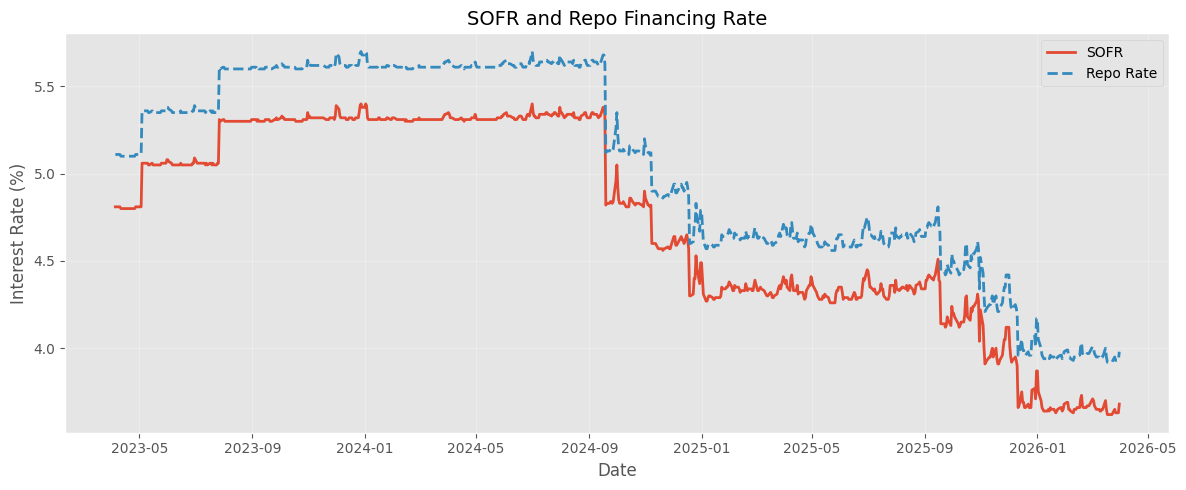

In [29]:
# ==========================
# SOFR vs Repo Rate
# ==========================

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["SOFR"] * 100,
    linewidth=2,
    label="SOFR"
)

plt.plot(
    df["Date"],
    df["Repo_Rate"] * 100,
    linewidth=2,
    linestyle="--",
    label="Repo Rate"
)

plt.title("SOFR and Repo Financing Rate", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Interest Rate (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

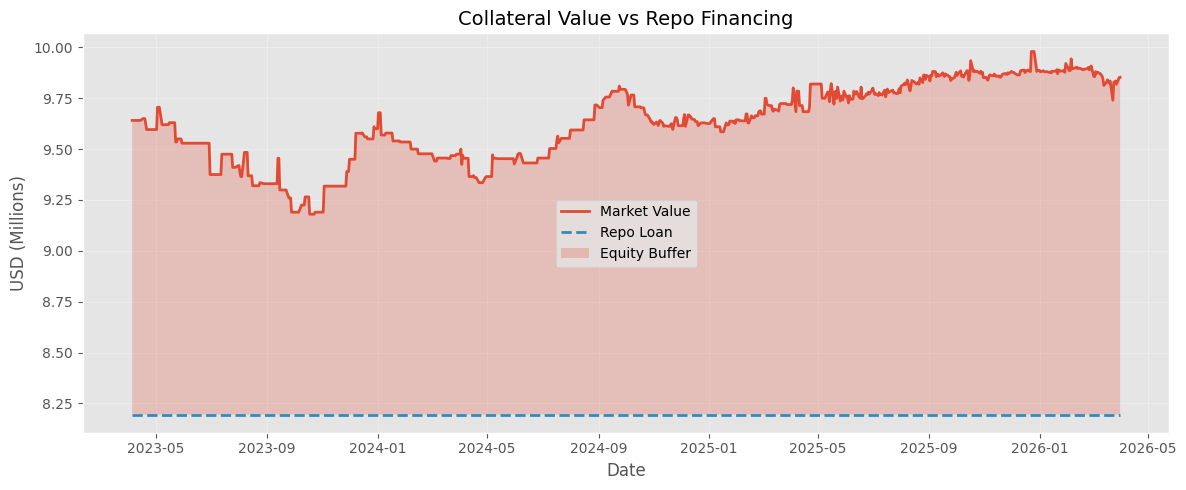

In [30]:
# ==========================
# Market Value vs Repo Loan
# ==========================

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Market_Value"] / 1e6,
    linewidth=2,
    label="Market Value"
)

plt.plot(
    df["Date"],
    df["Repo_Loan"] / 1e6,
    linewidth=2,
    linestyle="--",
    label="Repo Loan"
)

plt.fill_between(
    df["Date"],
    df["Repo_Loan"] / 1e6,
    df["Market_Value"] / 1e6,
    alpha=0.25,
    label="Equity Buffer"
)

plt.title("Collateral Value vs Repo Financing", fontsize=14)
plt.xlabel("Date")
plt.ylabel("USD (Millions)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

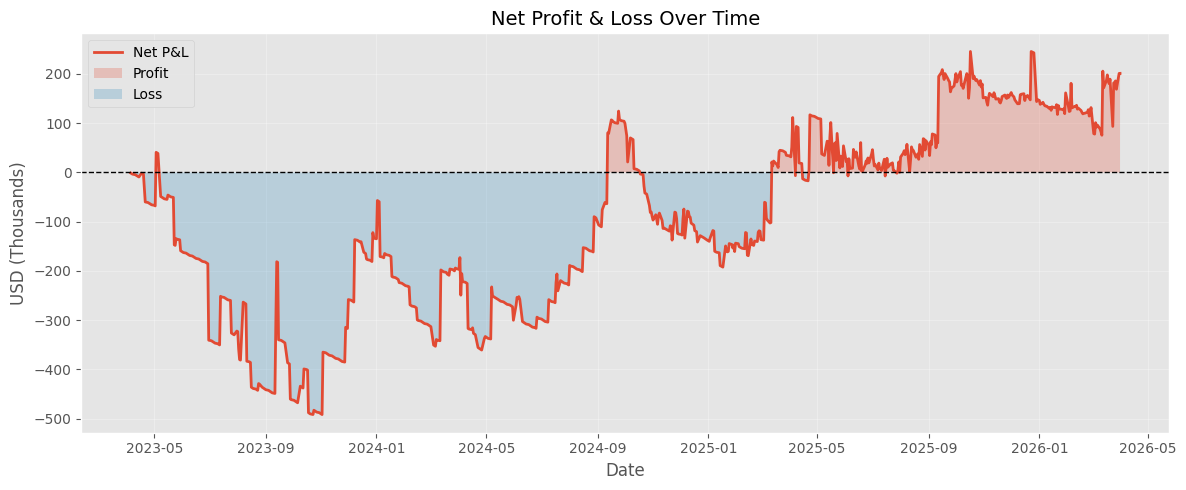

In [31]:
# ==========================
# Net P&L Evolution
# ==========================

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Net_PnL"] / 1e3,
    linewidth=2,
    label="Net P&L"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.fill_between(
    df["Date"],
    0,
    df["Net_PnL"] / 1e3,
    where=df["Net_PnL"] >= 0,
    alpha=0.25,
    label="Profit"
)

plt.fill_between(
    df["Date"],
    0,
    df["Net_PnL"] / 1e3,
    where=df["Net_PnL"] < 0,
    alpha=0.25,
    label="Loss"
)

plt.title("Net Profit & Loss Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("USD (Thousands)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

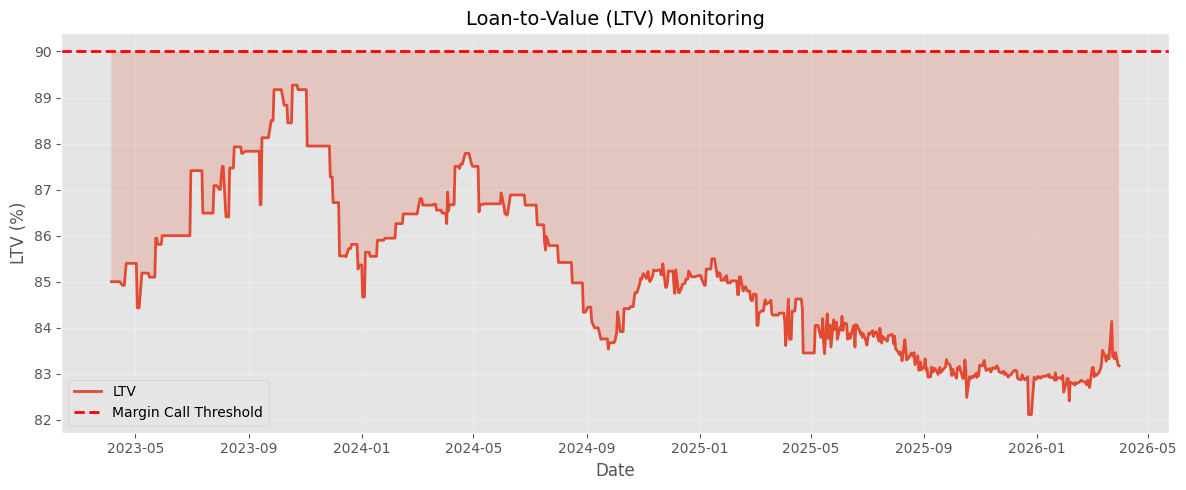

In [32]:
# ==========================
# Loan-to-Value (LTV) Monitoring
# ==========================

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["LTV"] * 100,
    linewidth=2,
    label="LTV"
)

plt.axhline(
    y=MARGIN_CALL_LTV * 100,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Margin Call Threshold"
)

plt.fill_between(
    df["Date"],
    df["LTV"] * 100,
    MARGIN_CALL_LTV * 100,
    where=df["LTV"] <= MARGIN_CALL_LTV,
    alpha=0.20
)

plt.title("Loan-to-Value (LTV) Monitoring", fontsize=14)
plt.xlabel("Date")
plt.ylabel("LTV (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

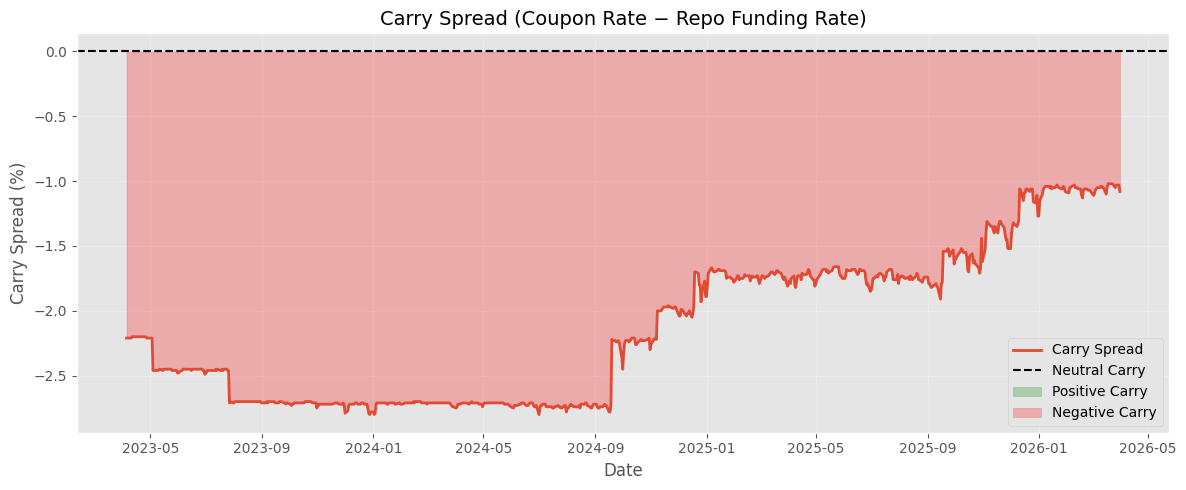

In [33]:
# ==========================
# Carry Spread Analysis
# ==========================

# Carry Spread = Coupon Rate - Repo Funding Rate
df["Carry_Spread"] = (COUPON_RATE - df["Repo_Rate"]) * 100

plt.figure(figsize=(12, 5))

# Carry Spread
plt.plot(
    df["Date"],
    df["Carry_Spread"],
    linewidth=2,
    label="Carry Spread"
)

# Neutral line
plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Neutral Carry"
)

# Positive Carry
plt.fill_between(
    df["Date"],
    0,
    df["Carry_Spread"],
    where=df["Carry_Spread"] >= 0,
    alpha=0.25,
    color="green",
    label="Positive Carry"
)

# Negative Carry
plt.fill_between(
    df["Date"],
    0,
    df["Carry_Spread"],
    where=df["Carry_Spread"] < 0,
    alpha=0.25,
    color="red",
    label="Negative Carry"
)

plt.title("Carry Spread (Coupon Rate − Repo Funding Rate)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Carry Spread (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
# ==========================
# Repo vs Unleveraged Comparison
# ==========================

# -------- Unleveraged Investment --------

unlev_initial_investment = INITIAL_MARKET_VALUE

unlev_coupon_income = df["Cumulative_Coupon_Income"].iloc[-1]

unlev_price_gain = df["Unrealized_PnL"].iloc[-1]

unlev_net_pnl = (
    unlev_coupon_income
    + unlev_price_gain
)

unlev_roe = (
    unlev_net_pnl
    / unlev_initial_investment
)

# -------- Repo-Financed Investment --------

repo_initial_investment = INITIAL_EQUITY

repo_coupon_income = df["Cumulative_Coupon_Income"].iloc[-1]

repo_price_gain = df["Unrealized_PnL"].iloc[-1]

repo_financing_cost = df["Cumulative_Financing_Cost"].iloc[-1]

repo_net_pnl = df["Net_PnL"].iloc[-1]

repo_roe = df["ROE"].iloc[-1]

# -------- Comparison Table --------

comparison = pd.DataFrame({
    "Metric": [
        "Capital Invested",
        "Coupon Income",
        "Price Appreciation",
        "Financing Cost",
        "Net P&L",
        "Return on Equity"
    ],
    "Unleveraged": [
        unlev_initial_investment,
        unlev_coupon_income,
        unlev_price_gain,
        0,
        unlev_net_pnl,
        unlev_roe
    ],
    "Repo Financed": [
        repo_initial_investment,
        repo_coupon_income,
        repo_price_gain,
        repo_financing_cost,
        repo_net_pnl,
        repo_roe
    ]
})

display(
    comparison.style.format({
        "Unleveraged": lambda x: (
            f"{x:.2%}" if abs(x) < 1 else f"${x:,.2f}"
        ),
        "Repo Financed": lambda x: (
            f"{x:.2%}" if abs(x) < 1 else f"${x:,.2f}"
        )
    })
)
print("Key Insight")
print("-" * 50)
print(
    f"Repo financing reduced the initial capital required by "
    f"{(1 - repo_initial_investment / unlev_initial_investment):.1%}, "
    f"while increasing the return on equity from "
    f"{unlev_roe:.2%} to {repo_roe:.2%}."
)

,Metric,Unleveraged,Repo Financed
0,Capital Invested,"$9,641,000.00","$1,446,150.00"
1,Coupon Income,"$870,000.00","$870,000.00"
2,Price Appreciation,"$212,000.00","$212,000.00"
3,Financing Cost,0.00%,"$880,769.01"
4,Net P&L,"$1,082,000.00","$201,230.99"
5,Return on Equity,11.22%,13.91%


Key Insight
--------------------------------------------------
Repo financing reduced the initial capital required by 85.0%, while increasing the return on equity from 11.22% to 13.91%.


In [35]:
# ==========================
# Repo Stress Testing
# ==========================

stress_shocks = [-0.05, -0.10, -0.15, -0.20]

stress_results = []

current_price = df["Price"].iloc[-1]

for shock in stress_shocks:

    stressed_price = current_price * (1 + shock)

    stressed_market_value = NUM_BONDS * (stressed_price / 100) * FACE_VALUE

    stressed_equity = stressed_market_value - INITIAL_REPO_LOAN

    stressed_ltv = INITIAL_REPO_LOAN / stressed_market_value

    margin_call = max(
        0,
        INITIAL_REPO_LOAN - (MARGIN_CALL_LTV * stressed_market_value)
    )

    stress_results.append({
        "Price Shock": f"{shock:.0%}",
        "Stressed Price": stressed_price,
        "Market Value": stressed_market_value,
        "Equity": stressed_equity,
        "LTV": stressed_ltv,
        "Margin Call": margin_call
    })

stress_df = pd.DataFrame(stress_results)

display(
    stress_df.style.format({
        "Stressed Price": "{:.2f}",
        "Market Value": "${:,.2f}",
        "Equity": "${:,.2f}",
        "LTV": "{:.2%}",
        "Margin Call": "${:,.2f}"
    })
)

,Price Shock,Stressed Price,Market Value,Equity,LTV,Margin Call
0,-5%,93.60,"$9,360,350.00","$1,165,500.00",87.55%,$0.00
1,-10%,88.68,"$8,867,700.00","$672,850.00",92.41%,"$213,920.00"
2,-15%,83.75,"$8,375,050.00","$180,200.00",97.85%,"$657,305.00"
3,-20%,78.82,"$7,882,400.00","$-312,450.00",103.96%,"$1,100,690.00"


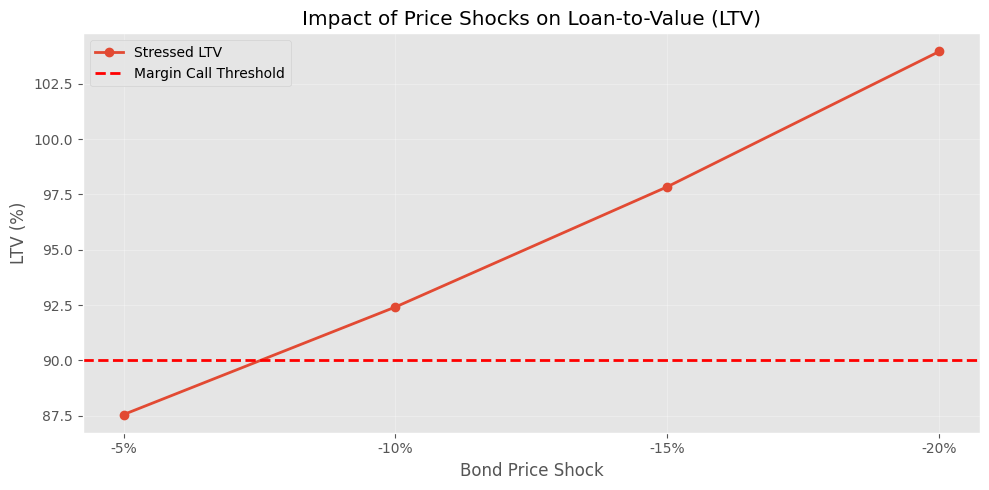

In [36]:
# ==========================
# Stress Test Visualization
# ==========================

plt.figure(figsize=(10,5))

plt.plot(
    stress_df["Price Shock"],
    stress_df["LTV"]*100,
    marker='o',
    linewidth=2,
    label="Stressed LTV"
)

plt.axhline(
    MARGIN_CALL_LTV*100,
    color='red',
    linestyle='--',
    linewidth=2,
    label="Margin Call Threshold"
)

plt.title("Impact of Price Shocks on Loan-to-Value (LTV)")
plt.xlabel("Bond Price Shock")
plt.ylabel("LTV (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Conclusion

This project simulated the financing of an investment-grade corporate bond using the repo market under historical market conditions. The analysis demonstrated how funding costs, coupon income, and bond price movements jointly determine portfolio performance. Although the position exhibited negative carry for most of the holding period, capital appreciation and coupon payments generated a positive overall return. A comparison with an unleveraged strategy highlighted the trade-off between higher absolute profits and improved capital efficiency through leverage, while stress testing illustrated the impact of adverse price shocks on leverage and margin requirements.